# 05 · Prediction, Forecasting & NLP

Three models that turn the earlier findings into tools the business could use:

| Part | Question | Technique |
|---|---|---|
| A | *At checkout*, which orders are likely to arrive late? | Gradient boosting vs logistic regression, time-based validation, leakage-safe seller history |
| B | How many orders should operations plan for next weeks? | Exponential smoothing vs naive baselines |
| C | What do unhappy customers write about? | TF-IDF + logistic regression on Portuguese review text |

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make the project package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import olist_analysis as oa

oa.set_style()
warnings.filterwarnings("ignore", category=DeprecationWarning)   # library-version noise, not relevant to results
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report, precision_recall_curve,
                             roc_auc_score, roc_curve, mean_absolute_error, mean_absolute_percentage_error)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df = oa.load_order_table()
WINDOW = (pd.Timestamp("2017-01-01"), pd.Timestamp("2018-08-31 23:59:59"))
dfw = df[df["order_purchase_timestamp"].between(*WINDOW)].copy()

---
## Part A · Predicting late delivery at checkout

**Leakage rules.** Only information available when the order is placed may be used: the promised date, distance, basket, payment,
time of day, how busy the platform is - and the **track record so far** of the seller and of the shipping lane (seller state →
customer state). Track records use only orders *delivered before* this order was placed (`merge_asof`), so the model never sees
the future.

**Validation.** Time-based split: train on orders placed **Jan 2017 - Mar 2018**, test on **Apr - Aug 2018**, exactly how the model
would be used in production. We also run the usual *random* split to show why that would be misleading here.

In [3]:
dlv = dfw[dfw["is_delivered"]].copy()


def track_record(orders, key, name, prior_rate=0.07, prior_weight=20):
    # Late rate of `key` (seller, lane, ...) using only deliveries completed BEFORE each order was placed.
    # Small histories are shrunk towards `prior_rate` (empirical-Bayes smoothing).
    ev = (df.loc[df["is_delivered"], key + ["order_delivered_customer_date", "is_late"]]
            .dropna(subset=key).sort_values("order_delivered_customer_date"))
    ev["_k"] = ev[key].astype(str).agg("|".join, axis=1)
    ev[f"{name}_n"] = ev.groupby("_k").cumcount() + 1
    ev[f"{name}_late"] = ev.groupby("_k")["is_late"].cumsum()
    left = orders.assign(_k=orders[key].astype(str).agg("|".join, axis=1)).sort_values("order_purchase_timestamp")
    out = pd.merge_asof(left, ev[["order_delivered_customer_date", "_k", f"{name}_n", f"{name}_late"]],
                        left_on="order_purchase_timestamp", right_on="order_delivered_customer_date", by="_k",
                        direction="backward", allow_exact_matches=False, suffixes=("", "_ev"))
    out[[f"{name}_n", f"{name}_late"]] = out[[f"{name}_n", f"{name}_late"]].fillna(0)
    out[f"{name}_late_rate"] = (out[f"{name}_late"] + prior_rate * prior_weight) / (out[f"{name}_n"] + prior_weight)
    return out.drop(columns=["_k", "order_delivered_customer_date_ev", f"{name}_late"])


dlv = track_record(dlv, ["main_seller_id"], "seller")
dlv = track_record(dlv, ["seller_state", "customer_state"], "lane")

# platform load: orders placed in the 7 days up to each purchase (busy periods -> congested carriers)
load = df.set_index("order_purchase_timestamp").sort_index()["order_id"].rolling("7D").count()
dlv["orders_last_7d"] = load.groupby(level=0).last().reindex(dlv["order_purchase_timestamp"]).values

dlv["purchase_dow"] = dlv["order_purchase_timestamp"].dt.dayofweek
top_cats = dlv["main_category"].value_counts().head(30).index
dlv["category_grp"] = dlv["main_category"].where(dlv["main_category"].isin(top_cats), "other")
dlv["same_state_num"] = dlv["same_state"].astype(int)

NUM = ["promised_days", "distance_km", "freight_value", "items_value", "total_weight_kg", "n_items", "n_sellers",
       "max_installments", "purchase_hour", "purchase_dow", "same_state_num",
       "seller_n", "seller_late_rate", "lane_late_rate", "orders_last_7d"]
CAT = ["customer_state", "seller_state", "category_grp", "payment_type"]
TARGET = "is_late"
# Note: calendar month is deliberately NOT a feature - it lets a model memorise one-off congestion episodes.

train = dlv[dlv["order_purchase_timestamp"] < "2018-04-01"]
test = dlv[dlv["order_purchase_timestamp"] >= "2018-04-01"]
X_train, y_train = train[NUM + CAT], train[TARGET].astype(int)
X_test, y_test = test[NUM + CAT], test[TARGET].astype(int)
print(f"Train: {len(train):,} orders, late rate {y_train.mean():.1%}")
print(f"Test:  {len(test):,} orders, late rate {y_test.mean():.1%}")

Train: 64,053 orders, late rate 8.0%
Test:  32,150 orders, late rate 4.4%


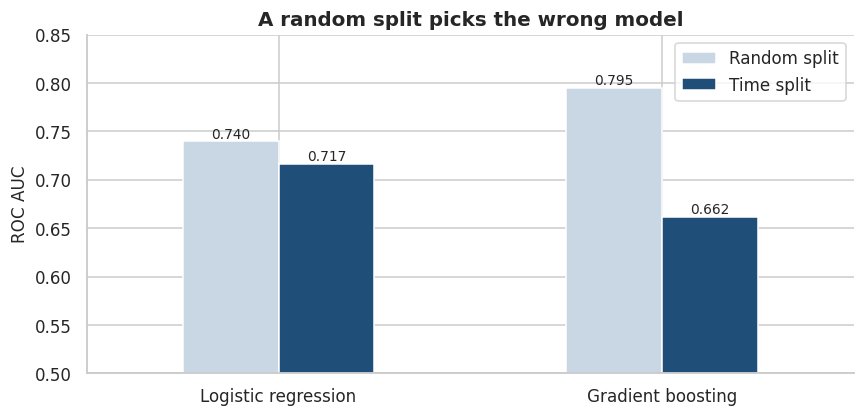

In [4]:
def make_models():
    logreg = make_pipeline(
        ColumnTransformer([
            ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUM),
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), CAT),
        ]),
        LogisticRegression(max_iter=3000, C=0.5),
    )
    hgb = make_pipeline(
        ColumnTransformer([
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CAT),
            ("num", "passthrough", NUM),
        ]),
        HistGradientBoostingClassifier(max_iter=300, learning_rate=0.04, max_leaf_nodes=15, min_samples_leaf=200,
                                       l2_regularization=2.0, categorical_features=list(range(len(CAT))), random_state=42),
    )
    return {"Logistic regression": logreg, "Gradient boosting": hgb}


def evaluate(train_df, test_df):
    scores, fitted, probs = {}, {}, {}
    for name, model in make_models().items():
        model.fit(train_df[NUM + CAT], train_df[TARGET].astype(int))
        p = model.predict_proba(test_df[NUM + CAT])[:, 1]
        y = test_df[TARGET].astype(int)
        scores[name] = {"ROC AUC": roc_auc_score(y, p), "PR AUC": average_precision_score(y, p)}
        fitted[name], probs[name] = model, p
    return scores, fitted, probs


rand_train, rand_test = train_test_split(dlv, test_size=0.33, stratify=dlv[TARGET], random_state=42)
random_scores, _, _ = evaluate(rand_train, rand_test)
time_scores, fitted, probs = evaluate(train, test)

comparison = pd.concat({"Random split": pd.DataFrame(random_scores).T, "Time split (realistic)": pd.DataFrame(time_scores).T}, axis=1)
display(comparison.style.format("{:.3f}"))
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pd.DataFrame({"Random split": {k: v["ROC AUC"] for k, v in random_scores.items()},
                        "Time split": {k: v["ROC AUC"] for k, v in time_scores.items()}})
plot_df.plot.bar(ax=ax, color=["#c9d6e3", oa.BASE], rot=0)
ax.set_ylim(0.5, 0.85)
ax.set_ylabel("ROC AUC")
ax.set_title("A random split picks the wrong model")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9)
oa.save(fig, "05_random_vs_time_split")
plt.show()

**Why this matters.** On a random split gradient boosting looks clearly better. On the realistic time split it is the *worst*
model: the trees memorise the congestion episodes of late 2017 / early 2018, which do not repeat in the test months (late rate
falls from 8.0 % to 4.4 %). The regularised logistic regression generalises better, so it is the model we would deploy.

Selected model: Logistic regression


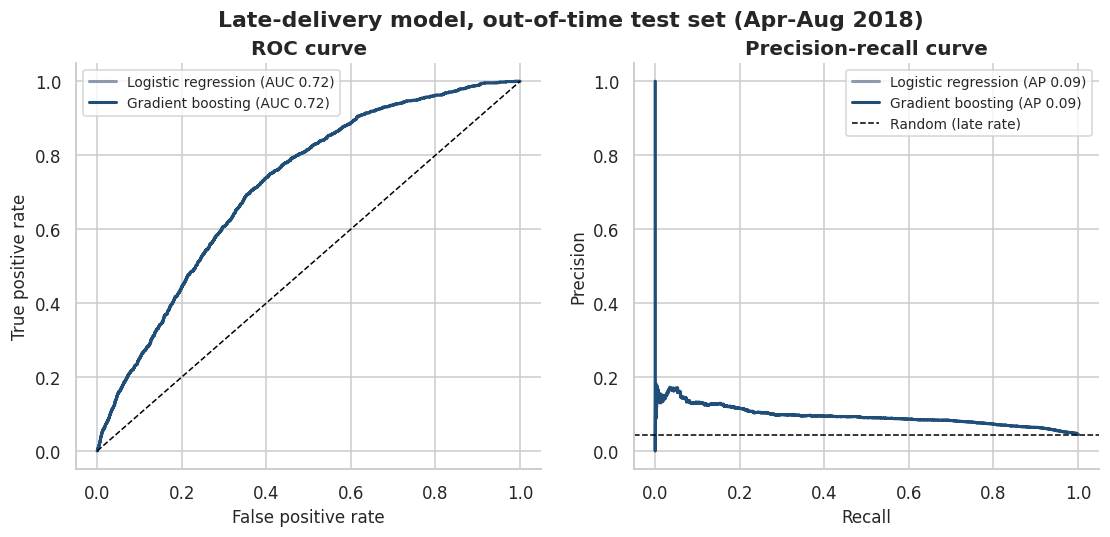

In [5]:
y_test = test[TARGET].astype(int)
final_name = max(time_scores, key=lambda k: time_scores[k]["PR AUC"])
final_model, p = fitted[final_name], probs[final_name]
print("Selected model:", final_name)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for (name, p_), color in zip(probs.items(), [oa.PALETTE[7], oa.BASE]):
    fpr, tpr, _ = roc_curve(y_test, p)
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC {roc_auc_score(y_test, p):.2f})")
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP {average_precision_score(y_test, p):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
axes[1].axhline(y_test.mean(), color="black", ls="--", lw=1, label="Random (late rate)")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
for ax in axes:
    ax.legend(loc="best", fontsize=9)
fig.suptitle("Late-delivery model, out-of-time test set (Apr-Aug 2018)", fontweight="bold")
oa.save(fig, "05_late_model_curves")
plt.show()

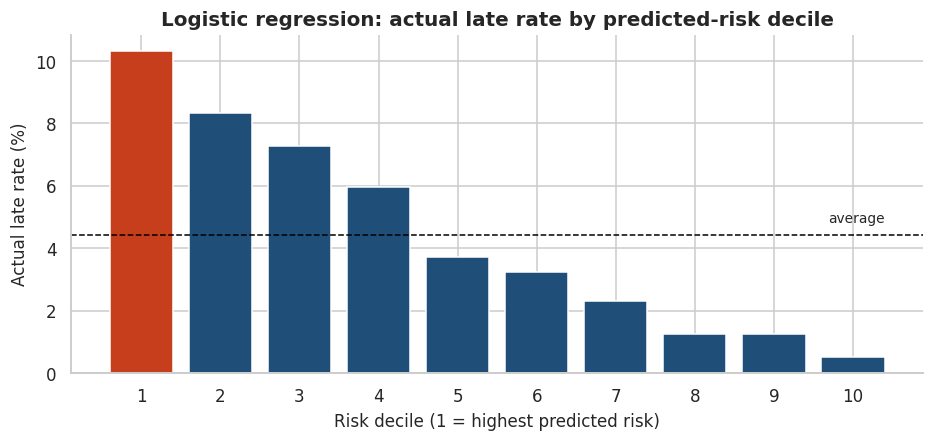

Top-decile late rate 10.3% vs average 4.4% -> lift 2.3x
Flagging the riskiest 10% of orders catches 23% of all late deliveries.


In [6]:
deciles = pd.qcut(pd.Series(p).rank(method="first"), 10, labels=range(10, 0, -1))
lift = (pd.DataFrame({"decile": deciles.values, "late": y_test.values})
          .groupby("decile", observed=True)["late"].mean().sort_index(ascending=False))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lift.index.astype(str), lift.values * 100, color=[oa.ACCENT] + [oa.BASE] * 9)
ax.axhline(y_test.mean() * 100, color="black", ls="--", lw=1)
ax.text(9.4, y_test.mean() * 100 + 0.4, "average", ha="right", fontsize=9)
ax.set_xlabel("Risk decile (1 = highest predicted risk)")
ax.set_ylabel("Actual late rate (%)")
ax.set_title(f"{final_name}: actual late rate by predicted-risk decile")
oa.save(fig, "05_lift_by_decile")
plt.show()
top10 = p >= np.quantile(p, 0.9)
print(f"Top-decile late rate {lift.iloc[0]:.1%} vs average {y_test.mean():.1%} -> lift {lift.iloc[0] / y_test.mean():.1f}x")
print(f"Flagging the riskiest 10% of orders catches {y_test[top10].sum() / y_test.sum():.0%} of all late deliveries.")

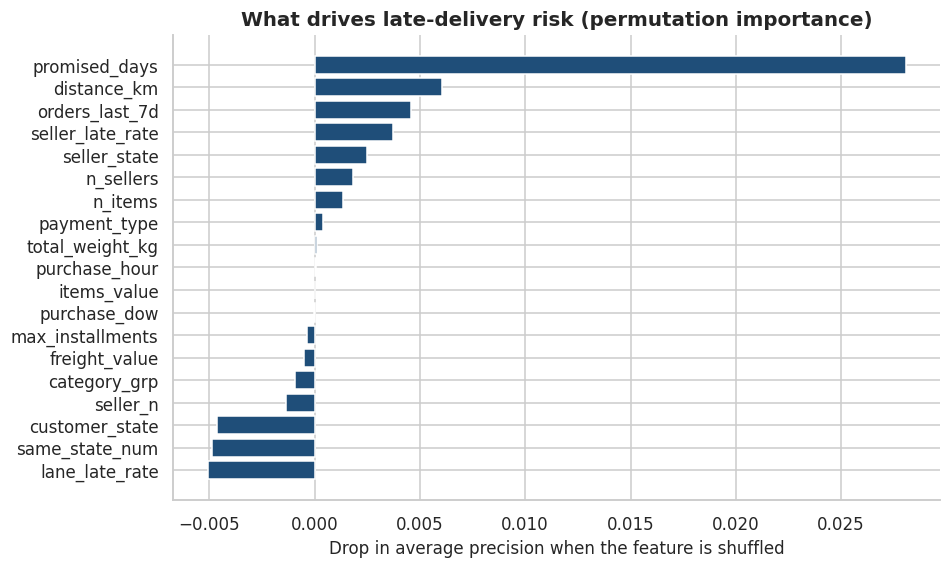

,importance
promised_days,0.0281
distance_km,0.0061
orders_last_7d,0.0046
seller_late_rate,0.0037
seller_state,0.0025
n_sellers,0.0018


In [7]:
X_test = test[NUM + CAT]
sub = X_test.sample(15_000, random_state=0)
imp = permutation_importance(final_model, sub, y_test.loc[sub.index], scoring="average_precision", n_repeats=5, random_state=0)
importance = pd.Series(imp.importances_mean, index=sub.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(importance.index, importance.values, color=oa.BASE)
ax.set_xlabel("Drop in average precision when the feature is shuffled")
ax.set_title("What drives late-delivery risk (permutation importance)")
oa.save(fig, "05_feature_importance")
plt.show()
importance.sort_values(ascending=False).head(6).to_frame("importance").style.format("{:.4f}")

---
## Part B · Weekly demand forecast

Operations needs to staff warehouses and book carrier capacity ahead. We forecast weekly orders and compare against two simple
baselines - a model is only useful if it beats them.

In [8]:
weekly = (dfw.set_index("order_purchase_timestamp").resample("W-SUN")["order_id"].count()
             .loc["2017-01-08":"2018-08-19"])
# The week ending 26 Aug 2018 has ~half the usual volume because the extract tails off - excluded as incomplete.
HOLDOUT = 12
train_w, test_w = weekly.iloc[:-HOLDOUT], weekly.iloc[-HOLDOUT:]

forecasts = {
    "Naive (last week)": pd.Series(train_w.iloc[-1], index=test_w.index),
    "4-week moving average": pd.Series(train_w.iloc[-4:].mean(), index=test_w.index),
    "Holt damped trend": ExponentialSmoothing(train_w, trend="add", damped_trend=True,
                                              initialization_method="estimated").fit().forecast(HOLDOUT),
}
scores = pd.DataFrame({name: {"MAE (orders/week)": mean_absolute_error(test_w, f),
                              "MAPE": mean_absolute_percentage_error(test_w, f)} for name, f in forecasts.items()}).T
scores.style.format({"MAE (orders/week)": "{:.0f}", "MAPE": "{:.1%}"})

,MAE (orders/week),MAPE
Naive (last week),574,34.5%
4-week moving average,286,21.4%
Holt damped trend,429,25.4%


Best model on the back-test: 4-week moving average


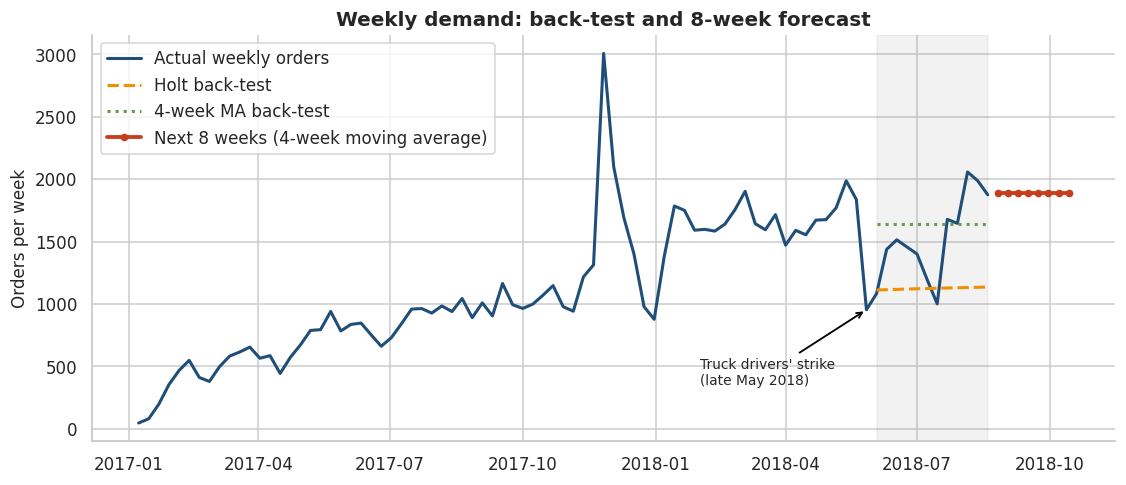

,2018-08-26,2018-09-02,2018-09-09,2018-09-16,2018-09-23,2018-09-30,2018-10-07,2018-10-14
forecast_orders,1892,1892,1892,1892,1892,1892,1892,1892


In [9]:
best = scores["MAE (orders/week)"].idxmin()
print("Best model on the back-test:", best)
if best == "Holt damped trend":
    future = ExponentialSmoothing(weekly, trend="add", damped_trend=True, initialization_method="estimated").fit().forecast(8)
elif best == "4-week moving average":
    future = pd.Series(weekly.iloc[-4:].mean(), index=pd.date_range(weekly.index[-1], periods=9, freq="W-SUN")[1:])
else:
    future = pd.Series(weekly.iloc[-1], index=pd.date_range(weekly.index[-1], periods=9, freq="W-SUN")[1:])

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(weekly.index, weekly.values, color=oa.BASE, lw=2, label="Actual weekly orders")
ax.plot(test_w.index, forecasts["Holt damped trend"].values, color=oa.PALETTE[2], lw=2, ls="--", label="Holt back-test")
ax.plot(test_w.index, forecasts["4-week moving average"].values, color=oa.PALETTE[5], lw=2, ls=":", label="4-week MA back-test")
ax.plot(future.index, future.values, color=oa.ACCENT, lw=2.5, marker="o", ms=4, label=f"Next 8 weeks ({best})")
strike = pd.Timestamp("2018-05-27")
ax.annotate("Truck drivers' strike\n(late May 2018)", xy=(strike, weekly.loc[strike]), xytext=(pd.Timestamp("2018-02-01"), 350),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2), fontsize=9)
ax.axvspan(test_w.index[0], test_w.index[-1], color="grey", alpha=0.1)
ax.set_ylabel("Orders per week")
ax.set_title("Weekly demand: back-test and 8-week forecast")
ax.legend(loc="upper left")
oa.save(fig, "05_weekly_forecast")
plt.show()
future.round().astype(int).to_frame("forecast_orders").T

**Result:** the simple 4-week moving average beats Holt's damped-trend model on the 12-week back-test. Demand stopped trending
upwards in 2018 and the hold-out contains shocks (the late-May 2018 truck drivers' strike, mid-year dips), so a model that
extrapolates trend over-reacts. With ~85 weeks of history - Black Friday appears only once - a yearly-seasonal model cannot be
estimated reliably. Recommendation: plan on a rolling 4-week average and add known events (Black Friday, strikes) as manual overrides.

---
## Part C · What unhappy customers write (NLP on Portuguese reviews)

In [10]:
rev = dfw.dropna(subset=["review_comment_message", "review_score"]).copy()
rev["text"] = (rev["review_comment_title"].fillna("") + " " + rev["review_comment_message"]).str.strip()
rev["low"] = rev["is_low_review"].astype(int)
print(f"Reviews with text: {len(rev):,} ({rev['low'].mean():.1%} are 1-2 stars)")

# Portuguese stop words (accents stripped). Negations such as 'nao' are deliberately KEPT - they carry the sentiment.
PT_STOP = ("a o as os de da do das dos e em no na nos nas um uma uns umas para por com que se ao aos "
           "foi ser sao era esta este essa esse isso isto ja me meu minha muito mais mas como eu ele ela "
           "voce lhe tem ter tinha pelo pela pelos pelas ou quando so sua seu suas seus").split()

X_tr, X_te, y_tr, y_te = train_test_split(rev["text"], rev["low"], test_size=0.2, stratify=rev["low"], random_state=42)
vec = TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2), min_df=5, max_df=0.9,
                      sublinear_tf=True, stop_words=PT_STOP)
clf = LogisticRegression(max_iter=3000, class_weight="balanced", C=2.0)
clf.fit(vec.fit_transform(X_tr), y_tr)
p_te = clf.predict_proba(vec.transform(X_te))[:, 1]
print(f"ROC AUC: {roc_auc_score(y_te, p_te):.3f}\n")
print(classification_report(y_te, (p_te >= 0.5).astype(int), target_names=["3-5 stars", "1-2 stars"], digits=3))

Reviews with text: 40,523 (26.5% are 1-2 stars)


ROC AUC: 0.957

              precision    recall  f1-score   support

   3-5 stars      0.970     0.886     0.926      5957
   1-2 stars      0.746     0.924     0.825      2148

    accuracy                          0.896      8105
   macro avg      0.858     0.905     0.876      8105
weighted avg      0.910     0.896     0.899      8105



In [11]:
GLOSSARY = {  # English meaning, shown next to the Portuguese term
    "nao": "not", "nao recebi": "did not receive", "recebi": "I received", "ainda": "still / yet",
    "ainda nao": "not yet", "nao chegou": "has not arrived", "chegou": "arrived", "entrega": "delivery",
    "prazo": "deadline / time frame", "antes do": "before the", "antes": "before", "dentro do": "within the",
    "recomendo": "I recommend", "otimo": "great", "excelente": "excellent", "bom": "good", "perfeito": "perfect",
    "adorei": "I loved it", "rapida": "fast", "rapido": "fast", "parabens": "congratulations", "lindo": "beautiful",
    "defeito": "defect", "errado": "wrong", "pessimo": "terrible", "pedido": "order", "veio": "came",
    "produto": "product", "devolver": "return", "comprei": "I bought", "aguardando": "waiting",
    "nao veio": "did not come", "recebi apenas": "only received", "apenas": "only", "faltando": "missing",
    "reclamacao": "complaint", "dinheiro": "money", "nenhuma": "none", "resposta": "reply",
    "cancelar": "cancel", "veio errado": "came wrong", "recebi produto": "received the product",
    "amei": "I loved it", "satisfeito": "satisfied", "qualidade": "quality", "agora": "now",
    "certo": "correct", "tudo certo": "all good", "chegou antes": "arrived early", "super": "super",
    "unidade": "unit", "unidades": "units", "outro": "another", "loja": "shop", "nada": "nothing",
    "ruim": "bad", "quebrado": "broken", "embalagem": "packaging", "gostei": "I liked it",
    "nao recomendo": "do not recommend", "nao gostei": "did not like", "pessima": "terrible", "horrivel": "horrible",
    "nem": "not even", "quero": "I want", "diferente": "different", "inferior": "inferior", "otima": "great",
    "obrigada": "thank you", "obrigado": "thank you", "boa": "good", "tudo": "everything", "lindos": "beautiful",
    "nao entregue": "not delivered", "nunca": "never", "falta": "missing", "estorno": "refund",
}
terms = np.array(vec.get_feature_names_out())
coef = clf.coef_[0]
neg_idx, pos_idx = np.argsort(coef)[-15:][::-1], np.argsort(coef)[:15]
words = pd.DataFrame({
    "drives 1-2 stars": terms[neg_idx], "meaning ": [GLOSSARY.get(t, "") for t in terms[neg_idx]],
    "drives 3-5 stars": terms[pos_idx], "meaning": [GLOSSARY.get(t, "") for t in terms[pos_idx]],
})
words

,drives 1-2 stars,meaning,drives 3-5 stars,meaning
0,nao,not,recomendo,I recommend
1,nao recomendo,do not recommend,perfeito,perfect
2,pessimo,terrible,parabens,congratulations
3,pessima,terrible,rapida,fast
4,comprei,I bought,antes,before
5,horrivel,horrible,lindo,beautiful
6,nao gostei,did not like,amei,I loved it
7,nem,not even,otimo,great
8,quero,I want,excelente,excellent
9,diferente,different,otima,great


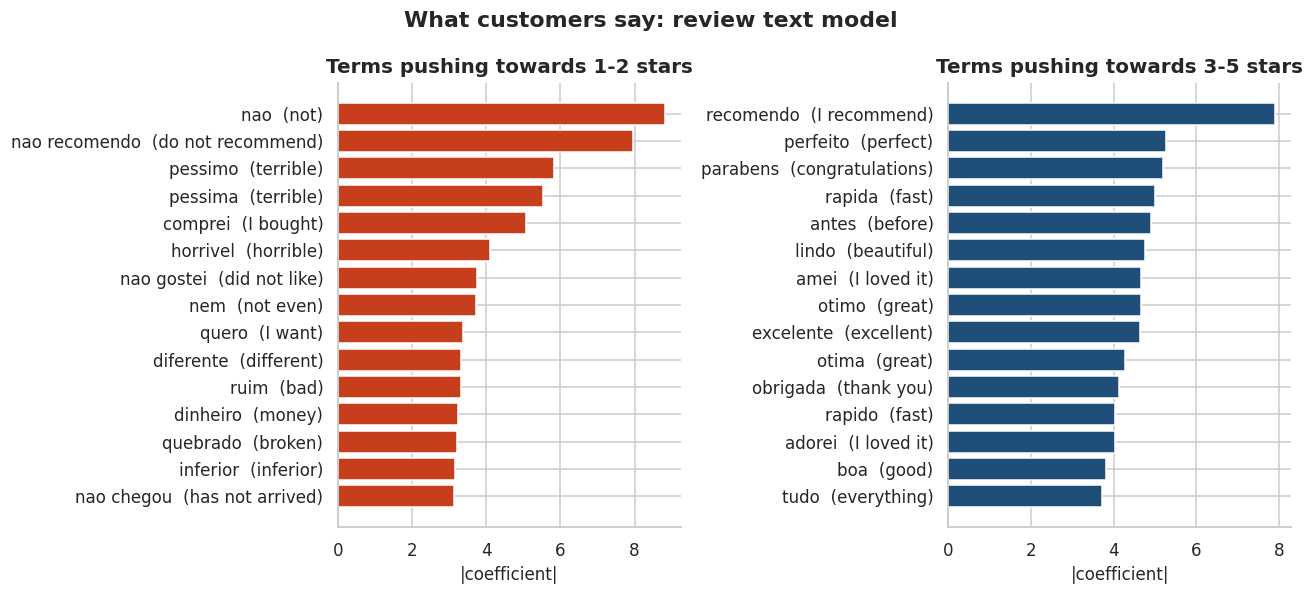

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, idx, color, title in [(axes[0], neg_idx, oa.ACCENT, "Terms pushing towards 1-2 stars"),
                              (axes[1], pos_idx, oa.BASE, "Terms pushing towards 3-5 stars")]:
    labels = [f"{t}  ({GLOSSARY[t]})" if t in GLOSSARY else t for t in terms[idx]]
    ax.barh(labels[::-1], np.abs(coef[idx])[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("|coefficient|")
fig.suptitle("What customers say: review text model", fontweight="bold")
fig.tight_layout()
oa.save(fig, "05_review_terms")
plt.show()

In [13]:
delivery_words = r"\b(?:entrega|entregue|prazo|chegou|recebi|receb|atras|aguardando|ainda nao)"
rev["mentions_delivery"] = rev["text"].str.lower().str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii") \
                                      .str.contains(delivery_words, regex=True)
share = rev.groupby(rev["low"].map({0: "3-5 star reviews", 1: "1-2 star reviews"}))["mentions_delivery"].mean()
print(share.map("{:.0%}".format).to_string())

examples = pd.Series(["Produto chegou antes do prazo, recomendo a loja",
                      "Ainda nao recebi o produto e ja passou do prazo",
                      "Veio com defeito e quero devolver"])
pd.DataFrame({"review": examples, "P(1-2 stars)": clf.predict_proba(vec.transform(examples))[:, 1].round(2)})

low
1-2 star reviews    65%
3-5 star reviews    49%


,review,P(1-2 stars)
0,"Produto chegou antes do prazo, recomendo a loja",0.00
1,Ainda nao recebi o produto e ja passou do prazo,0.95
2,Veio com defeito e quero devolver,0.95


## Summary

* **Late-delivery model (honest result).** On a random split gradient boosting looks best (ROC AUC 0.795), but on the realistic
  time split it drops to 0.662 while regularised logistic regression holds **0.717** (PR AUC 0.094 vs a 0.044 baseline). Flagging the
  riskiest 10 % of orders catches **23 %** of late deliveries at **2.3x** the average late rate. The promised lead time, distance,
  platform load and the seller's track record matter most. Lateness is driven largely by events that are hard to see at checkout
  (carrier congestion, strikes), so this works as a **risk flag**, not an oracle.
* **Demand forecast.** The simple **4-week moving average** beat Holt's damped trend on a 12-week back-test (MAPE 21 % vs 25 %);
  the hold-out contained the late-May 2018 truck drivers' strike. Plan on the rolling average plus manual event overrides.
* **Review NLP.** A transparent TF-IDF + logistic regression model reaches **ROC AUC 0.957** and catches 92 % of 1-2★ reviews.
  Its strongest negative terms are *não recomendo*, *péssimo*, *não chegou* ("has not arrived"); delivery vocabulary appears in
  **65 %** of negative reviews (and 49 % of positive ones - delivery is what customers talk about either way).

⬅️ Back to the [project README](../README.md)